# 🏦 Bank Marketing Campaign Success Prediction using K-Nearest Neighbors (KNN)

## Business Problem

Banks spend significant time and money contacting customers during marketing campaigns to promote term deposit subscriptions. However, contacting every customer is inefficient because many are not interested.

The goal of this project is to build a **K-Nearest Neighbors (KNN)** classification model that predicts whether a customer is likely to subscribe to a **term deposit** based on their demographic, financial, and previous marketing campaign information.

By identifying customers with a higher probability of subscribing, banks can:

- Reduce unnecessary marketing costs.
- Improve campaign efficiency.
- Increase conversion rates.
- Focus marketing efforts on potential customers.
- Make data-driven business decisions.


In [1]:
# import libraries

import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.neighbors import KNeighborsClassifier


In [2]:
# Load Dataset

df = pd.read_csv('bank.csv')
df.head(5)

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,59,admin.,married,secondary,no,2343,yes,no,unknown,5,may,1042,1,-1,0,unknown,yes
1,56,admin.,married,secondary,no,45,no,no,unknown,5,may,1467,1,-1,0,unknown,yes
2,41,technician,married,secondary,no,1270,yes,no,unknown,5,may,1389,1,-1,0,unknown,yes
3,55,services,married,secondary,no,2476,yes,no,unknown,5,may,579,1,-1,0,unknown,yes
4,54,admin.,married,tertiary,no,184,no,no,unknown,5,may,673,2,-1,0,unknown,yes


In [3]:
df.tail()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
11157,33,blue-collar,single,primary,no,1,yes,no,cellular,20,apr,257,1,-1,0,unknown,no
11158,39,services,married,secondary,no,733,no,no,unknown,16,jun,83,4,-1,0,unknown,no
11159,32,technician,single,secondary,no,29,no,no,cellular,19,aug,156,2,-1,0,unknown,no
11160,43,technician,married,secondary,no,0,no,yes,cellular,8,may,9,2,172,5,failure,no
11161,34,technician,married,secondary,no,0,no,no,cellular,9,jul,628,1,-1,0,unknown,no


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11162 entries, 0 to 11161
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        11162 non-null  int64 
 1   job        11162 non-null  object
 2   marital    11162 non-null  object
 3   education  11162 non-null  object
 4   default    11162 non-null  object
 5   balance    11162 non-null  int64 
 6   housing    11162 non-null  object
 7   loan       11162 non-null  object
 8   contact    11162 non-null  object
 9   day        11162 non-null  int64 
 10  month      11162 non-null  object
 11  duration   11162 non-null  int64 
 12  campaign   11162 non-null  int64 
 13  pdays      11162 non-null  int64 
 14  previous   11162 non-null  int64 
 15  poutcome   11162 non-null  object
 16  deposit    11162 non-null  object
dtypes: int64(7), object(10)
memory usage: 1.4+ MB


In [5]:
missing_values = df.isnull().sum().sort_values(ascending=False)
missing_values

age          0
day          0
poutcome     0
previous     0
pdays        0
campaign     0
duration     0
month        0
contact      0
job          0
loan         0
housing      0
balance      0
default      0
education    0
marital      0
deposit      0
dtype: int64

In [6]:
df.columns

Index(['age', 'job', 'marital', 'education', 'default', 'balance', 'housing',
       'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'deposit'],
      dtype='object')

In [7]:
duplicate_values = df.duplicated()
duplicate_values

0        False
1        False
2        False
3        False
4        False
         ...  
11157    False
11158    False
11159    False
11160    False
11161    False
Length: 11162, dtype: bool

In [8]:
# Target Analysis

plt.figure(figsize=(5,4))
sns.countplot(x=df['deposit'])
plt.title('Target Variable ')
plt.show()

<Figure size 500x400 with 1 Axes>

In [9]:
class_counts = df['deposit'].value_counts()
class_counts

deposit
no     5873
yes    5289
Name: count, dtype: int64

## Exploratory Data Analysis (EDA)

In [10]:
# Convert target feature to binary values 
df['y_encoded'] = df['deposit'].map({'no': 0, 'yes': 1}) 


# Separate numerical features and categorical features 

numerical_features = df.select_dtypes(include=[np.number]).columns
categorial_features = df.select_dtypes(include=['object']).columns

### Distribution of Numerical Features 

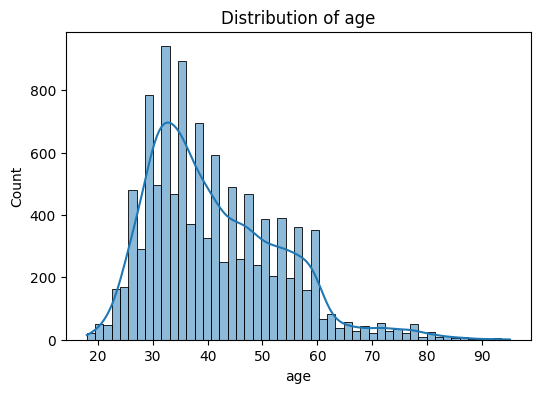

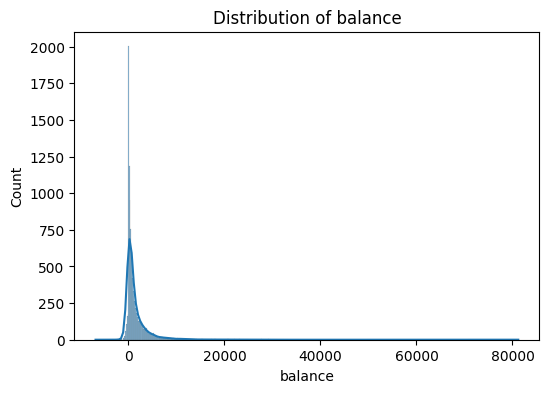

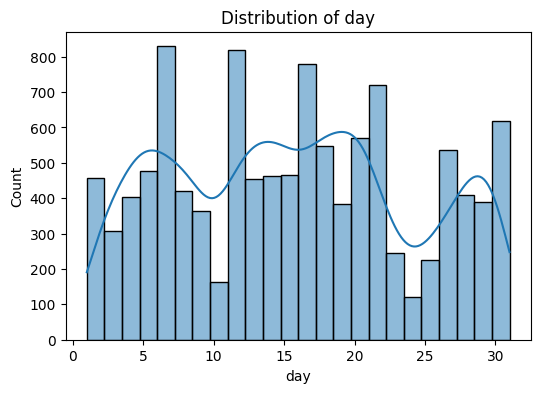

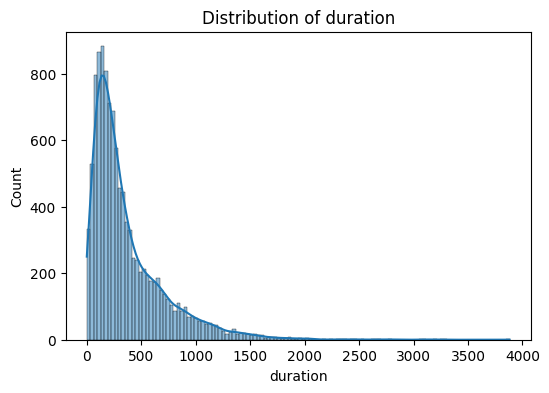

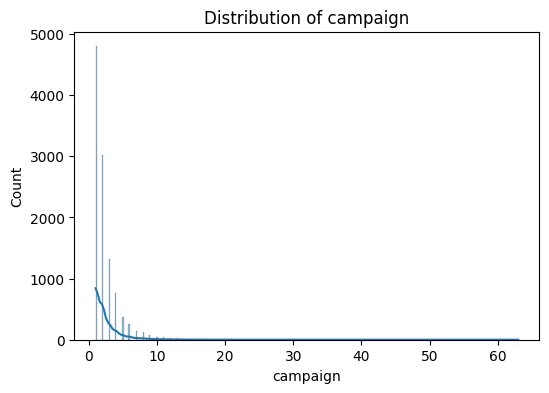

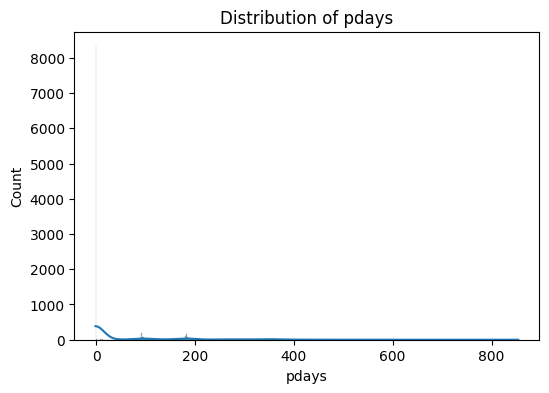

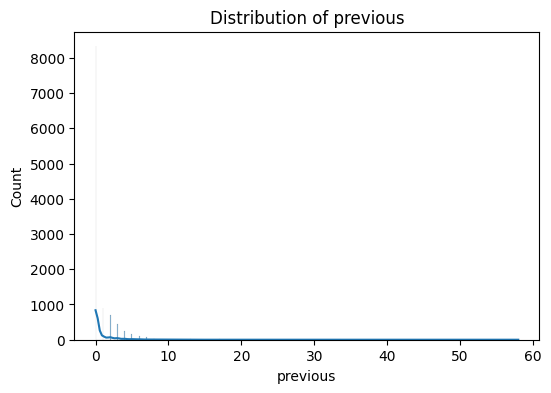

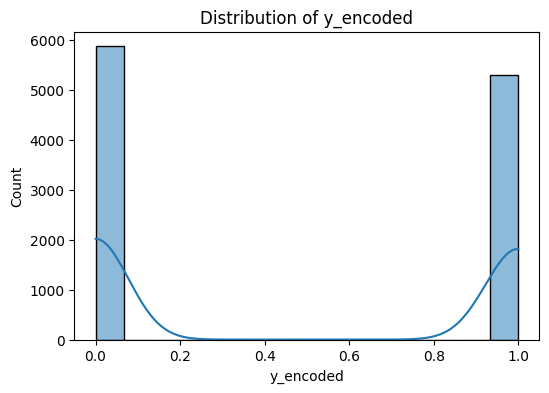

In [11]:
for col in numerical_features: 
    plt.figure(figsize=(6,4))
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribution of {col}')
    plt.show()

There are most columns that are highly right-skewed, log1p  transformation will requried in pre-processing before scaling. 
There is also sentinel code in pdays columns -1, which means never contacted. 

To handle sentinel code, i will first create a binary feature of never contacted 'never_contacted' from pdays (filtering) and then replace -1 with 0 in pdays col. 

### Sentinel Code in Pdays

In [12]:
# sentinel code for pdays = -1

specialcode = df[df['pdays'] == -1]
specialcode

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit,y_encoded
0,59,admin.,married,secondary,no,2343,yes,no,unknown,5,may,1042,1,-1,0,unknown,yes,1
1,56,admin.,married,secondary,no,45,no,no,unknown,5,may,1467,1,-1,0,unknown,yes,1
2,41,technician,married,secondary,no,1270,yes,no,unknown,5,may,1389,1,-1,0,unknown,yes,1
3,55,services,married,secondary,no,2476,yes,no,unknown,5,may,579,1,-1,0,unknown,yes,1
4,54,admin.,married,tertiary,no,184,no,no,unknown,5,may,673,2,-1,0,unknown,yes,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11156,34,blue-collar,single,secondary,no,-72,yes,no,cellular,7,jul,273,5,-1,0,unknown,no,0
11157,33,blue-collar,single,primary,no,1,yes,no,cellular,20,apr,257,1,-1,0,unknown,no,0
11158,39,services,married,secondary,no,733,no,no,unknown,16,jun,83,4,-1,0,unknown,no,0
11159,32,technician,single,secondary,no,29,no,no,cellular,19,aug,156,2,-1,0,unknown,no,0


Pdays feature have sentinel/special code '-1' which means 'never contacted'. The histogram is right-skewed , so if we apply log1p , model will think customer has contacted after very long time, which is wrong. It will Completely Change it's meaning 

In [13]:
# Handling sentinel code 

# create another binary feature 'never_contacted' by using pdays feature 
# then fill '-1' or  sentienl code a nan by 0

# Now i can apply log1p 

df["never_contacted"] = (df["pdays"] == -1).astype(int)

In [14]:
dfs = pd.read_csv('bank.csv')

df['pdays'] = dfs['pdays']

In [15]:
df['pdays'] = df['pdays'].replace(-1,0)

In [16]:
df['pdays'].value_counts()

pdays
0      8324
92      106
182      89
91       84
181      81
       ... 
437       1
728       1
518       1
828       1
118       1
Name: count, Length: 472, dtype: int64

In [17]:
df["pdays"].isna().sum()

0

### Distriubtion of Pdays after Handling special codes

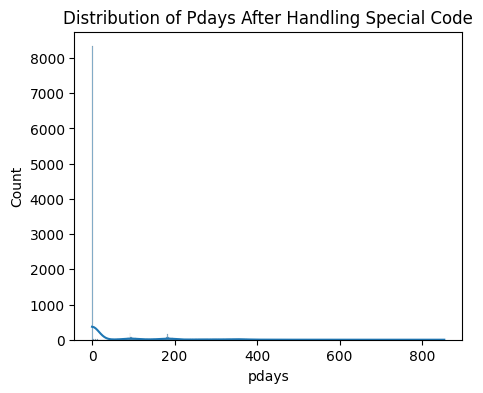

In [18]:
plt.figure(figsize=(5,4))
sns.histplot(x=df['pdays'],kde=True)
plt.title('Distribution of Pdays After Handling Special Code')
plt.show()

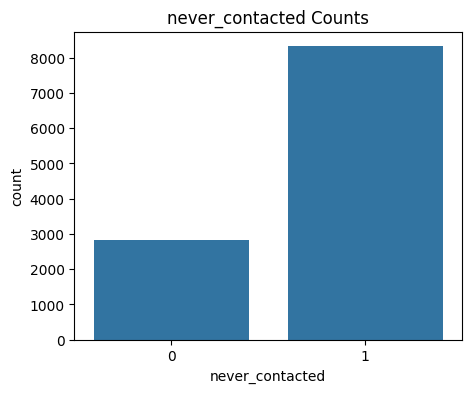

In [19]:
plt.figure(figsize=(5,4))
sns.countplot(x=df['never_contacted'])
plt.title('never_contacted Counts')
plt.show()

### Boxplot of Numerical Cols

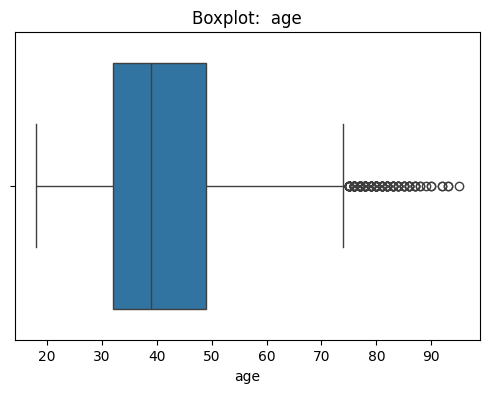

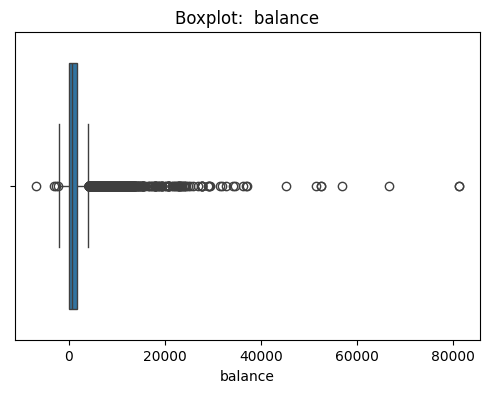

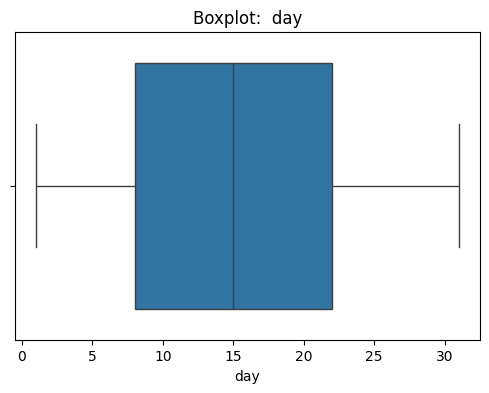

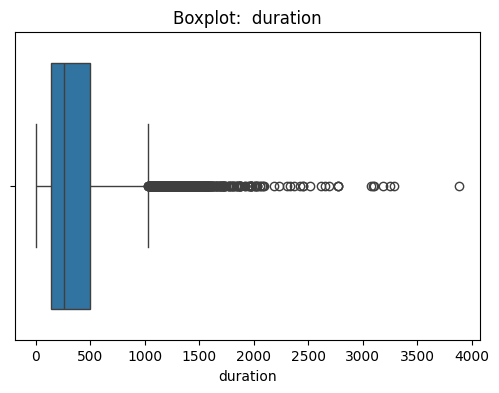

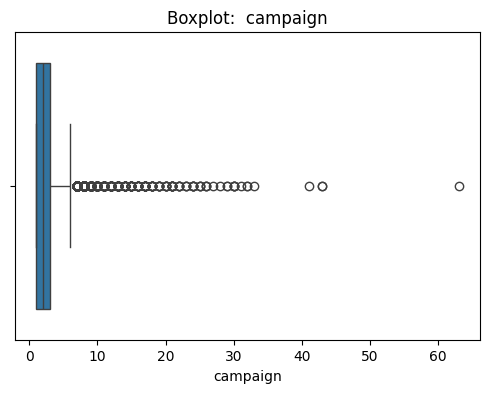

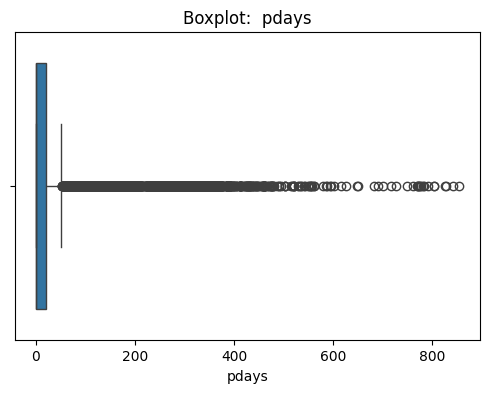

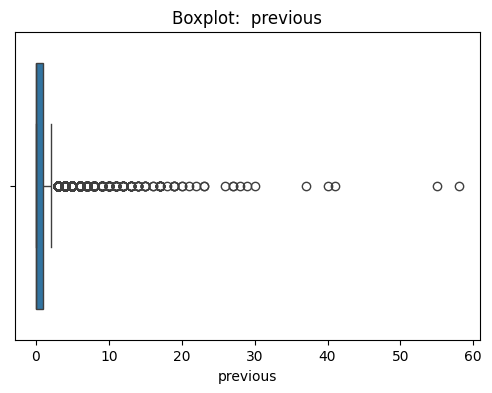

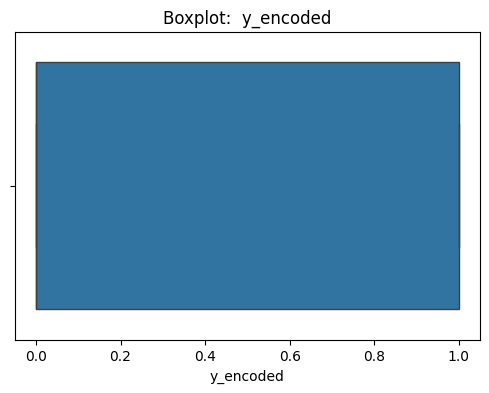

In [20]:
for col in numerical_features:
    plt.figure(figsize=(6,4))
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot:  {col}')
    plt.show()

There are several high observations which is identified by IQR, but it seems real customers value. They should be keeped, rather than remove.

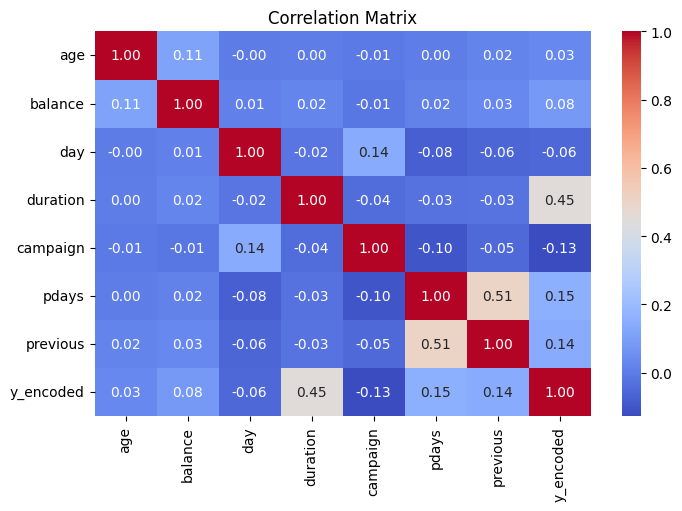

In [21]:
corr_matrix = df[numerical_features].corr() 


plt.figure(figsize=(8,5))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix')
plt.show()

### Technical insight:

duration has the strongest linear relation with the target (r = 0.45), while pdays and never_contacted show strong feature-to-feature correlation (r = -0.82), indicating potential redundancy, can cause multicollinearity issue. 

### Business insights

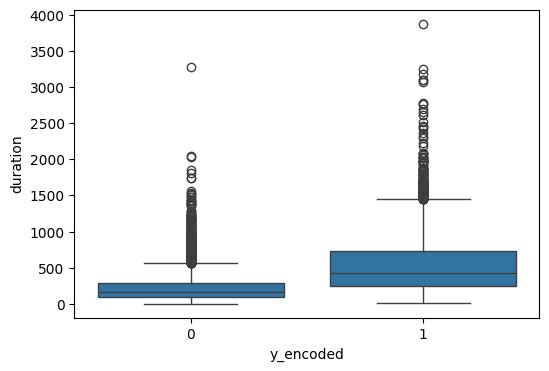

In [22]:
plt.figure(figsize=(6,4))
sns.boxplot(data=df, x='y_encoded', y='duration')
plt.show()

Customers who subscribed generally had longer call durations than customers who did not subscribe.

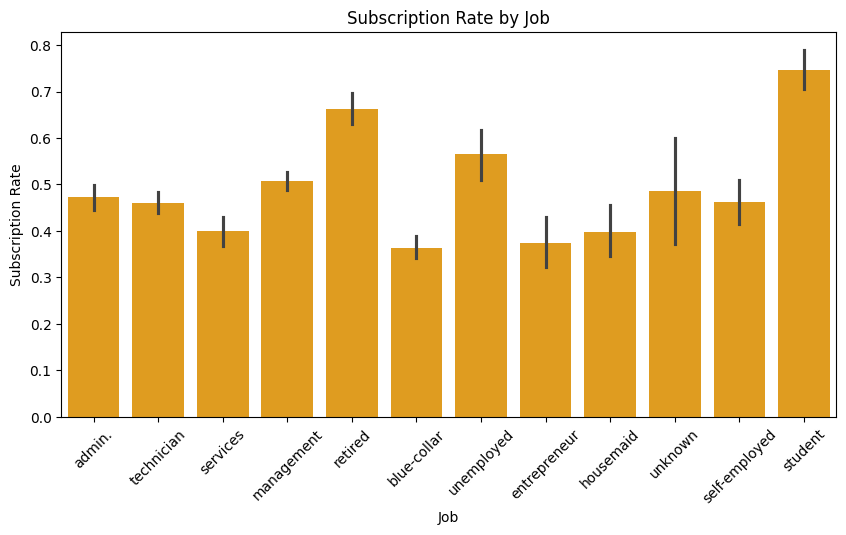

In [23]:
# Which occupation has the highest subscription rate? 

plt.figure(figsize=(10, 5))

sns.barplot(data=df,x='job',y='y_encoded',color='orange')
plt.xlabel("Job")
plt.ylabel("Subscription Rate")
plt.title("Subscription Rate by Job")
plt.xticks(rotation=45)
plt.show()

Barplot is plotted to observe, which occupation have how much percentage to subscribe. And we came to know that Students and retired customers have the highest observed subscription rates, while blue-collar, entrepreneur, and service occupations and other jobs have comparatively lower subscription rates.

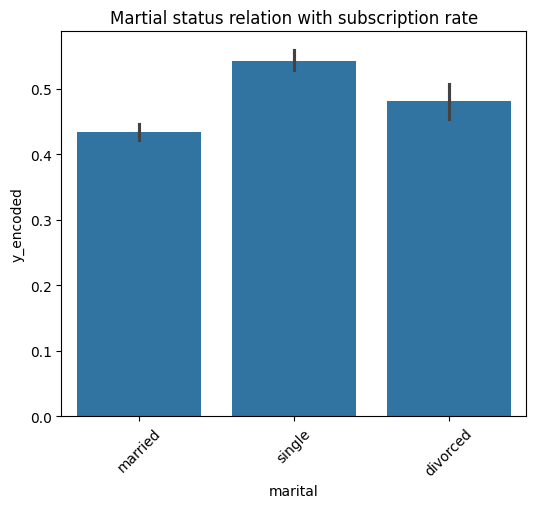

In [24]:
plt.figure(figsize=(6,5))
sns.barplot(data=df, x='marital',y='y_encoded')
plt.title('Martial status relation with subscription rate')
plt.xticks(rotation=45)
plt.show()

In [25]:
df.groupby('marital')['y_encoded'].agg(['mean','count'])

,mean,count
marital,,
divorced,0.481052,1293
married,0.433790,6351
single,0.543491,3518


After Analyzing Error bars, Subscription rates differ across marital-status groups, with single customers showing the highest observed rate (54.3%) and married customers the lowest (43.4%).

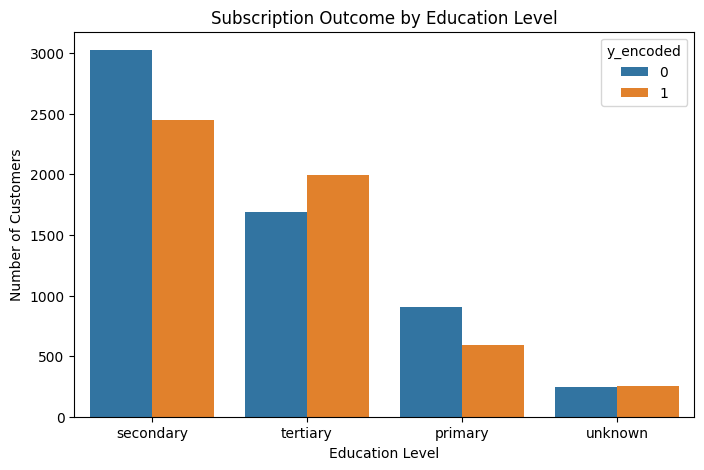

In [26]:
plt.figure(figsize=(8, 5))

sns.countplot(data=df,x='education',hue='y_encoded')
plt.xlabel("Education Level")
plt.ylabel("Number of Customers")
plt.title("Subscription Outcome by Education Level")

plt.show()

In [27]:
df.groupby('education')['y_encoded'].agg(['mean', 'count']).sort_values(
    'mean',
    ascending=False
)

,mean,count
education,,
tertiary,0.541068,3689
unknown,0.507042,497
secondary,0.447407,5476
primary,0.394000,1500


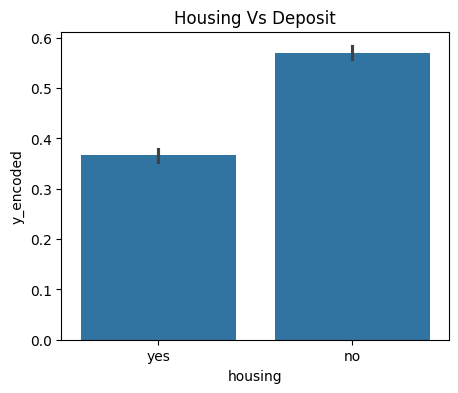

In [30]:
# Housing vs deposit 

plt.figure(figsize=(5,4))
sns.barplot(data=df, x='housing', y='y_encoded')
plt.title("Housing Vs Deposit")
plt.show()

Barplot was created to observe the relationship between Housing and Deposit, and we observed that Customer with Housing loan's subscription rate is comparitevly low with 38% than customer with no housing loan 56%. 

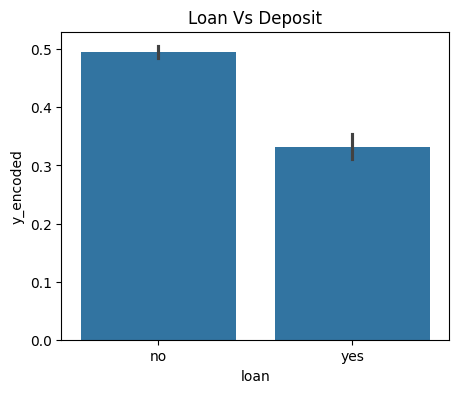

In [31]:
# loan vs Deposit

plt.figure(figsize=(5,4))
sns.barplot(data=df, x='loan', y='y_encoded')
plt.title('Loan Vs Deposit')
plt.show()

I Observed that customer with no loan is more subscribe reate with 49% while the customer with loan is tend to have lower subscription reate of 32%.  

## Data Pre-processing 

In [32]:
# Split the data before preprocessing 

x = df.drop(columns=['deposit','y_encoded'])
y = df['y_encoded'] 


In [44]:
x_train,x_test,y_train,y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)



In [46]:
# Apply log1p tranformation to reduce skewness in the features 

x_train_pdays = np.log1p(df['pdays'])
x_test_pdays = np.log1p(df['pdays'])

x_train_balance = np.log1p(df['balance'])
x_test_balance = np.log1p(df['balance'])

x_train_duration = np.log1p(df['duration'])
x_test_duration = np.log1p(df['duration'])

x_train_campaign = np.log1p(df['campaign'])
x_test_campaign = np.log1p(df['campaign'])

x_train_previous = np.log1p(df['previous'])
x_test_previous = np.log1p(df['previous'])



C:\Users\Admin\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)
C:\Users\Admin\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [51]:
categorial_features

Index(['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact',
       'month', 'poutcome', 'deposit'],
      dtype='object')

In [48]:
# Scaling 

scaler = StandardScaler()

scaler.fit(x_train[['age','balance','day','campaign','previous','pdays','duration']])

x_train_scaled = scaler.transform(x_train[['age','balance','day','campaign','previous','pdays','duration']])
x_test_scaled = scaler.transform(x_test[['age','balance','day','campaign','previous','pdays','duration']])

In [ ]:
# Encoding Categorical Features 

encoder = OneHotEncoder(handle_unknown='ignore')

encoder.fit(x_train[['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact',
       'month', 'poutcome']])


x_train_encoded = encoder.transform(x_train[['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact',
       'month', 'poutcome']])
x_test_encoded = encoder.transform(x_test[['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact',
       'month', 'poutcome']])




In [59]:
x_train_encoded = x_train_encoded.toarray()
x_test_encoded = x_test_encoded.toarray()


In [60]:
# Combine encoded and scaled features togather 

x_train_processed = np.hstack((x_train_encoded,x_train_scaled))
x_test_processed = np.hstack((x_test_encoded, x_test_scaled))


In [63]:
print(f'x_train_processed', {x_train_processed.shape})
print(f'x_test_processed' ,{x_test_processed.shape})


x_train_processed {(8929, 51)}
x_test_processed {(2233, 51)}


## KNN Model

In [64]:
# train knn model 

knn_model = KNeighborsClassifier()

knn_model.fit(x_train_processed,y_train)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [65]:
# make prediction 
y_pred = knn_model.predict(x_test_processed)

## Evaluation

In [66]:
# Evaluate knn model 

from sklearn.metrics import accuracy_score, classification_report , confusion_matrix

accuracy = accuracy_score(y_test, y_pred)
class_report = classification_report(y_test,y_pred)
conf_matrix = confusion_matrix(y_test,y_pred)

print(f'Accuracy: {accuracy}')
print(f'Confusion Matrix: \n {conf_matrix}')
print(f'Classification Report : \n {class_report}')


Accuracy: 0.8168383340797134
Confusion Matrix: 
 [[992 183]
 [226 832]]
Classification Report : 
               precision    recall  f1-score   support

           0       0.81      0.84      0.83      1175
           1       0.82      0.79      0.80      1058

    accuracy                           0.82      2233
   macro avg       0.82      0.82      0.82      2233
weighted avg       0.82      0.82      0.82      2233



The KNN classifier achieved an accuracy of 81.7% on the test set. Performance was balanced across both classes, with F1-scores of 0.83 for non-subscribers and 0.80 for subscribers. For the positive class, the model achieved 82% precision and 79% recall, correctly identifying most subscribers while missing approximately 21% of actual subscribers.

### Cross-validation 

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

results = []

for k in range(1, 21,2): # Try different k values from range of 1 to 21 

    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(x_train_processed, y_train)

    y_pred = knn.predict(x_test_processed)

    results.append({
        'k': k,
        'accuracy': accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred),
        'recall': recall_score(y_test, y_pred),
        'f1': f1_score(y_test, y_pred)
    })

results_df = pd.DataFrame(results)

print(results_df)

    k  accuracy  precision    recall        f1
0   1  0.770712   0.781443  0.716446  0.747535
1   3  0.797582   0.802395  0.759924  0.780583
2   5  0.816838   0.819704  0.786389  0.802701
3   7  0.822660   0.828373  0.789225  0.808325
4   9  0.820869   0.825743  0.788280  0.806576
5  11  0.824004   0.836198  0.781664  0.808012
6  13  0.819077   0.828313  0.779773  0.803311
7  15  0.819525   0.829146  0.779773  0.803702
8  17  0.820421   0.828172  0.783554  0.805245
9  19  0.819973   0.828657  0.781664  0.804475


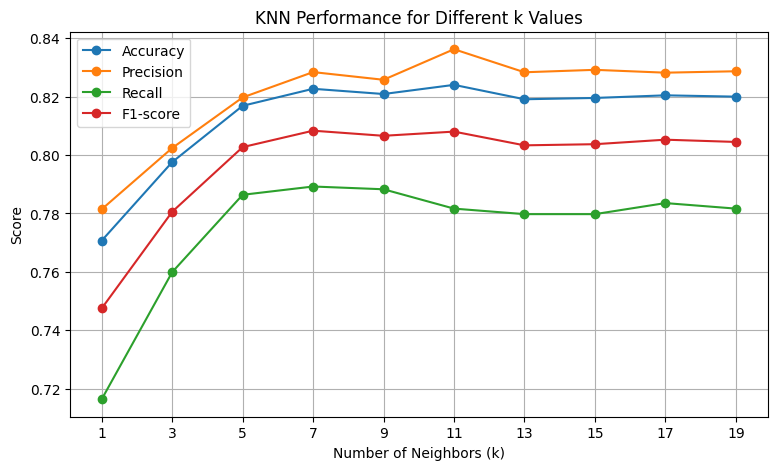

In [69]:
plt.figure(figsize=(9, 5))

plt.plot(results_df['k'], results_df['accuracy'], marker='o', label='Accuracy')
plt.plot(results_df['k'], results_df['precision'], marker='o', label='Precision')
plt.plot(results_df['k'], results_df['recall'], marker='o', label='Recall')
plt.plot(results_df['k'], results_df['f1'], marker='o', label='F1-score')

plt.xlabel('Number of Neighbors (k)')
plt.ylabel('Score')
plt.title('KNN Performance for Different k Values')
plt.xticks(results_df['k'])
plt.legend()
plt.grid(True)

plt.show()

## Final KNN Model —> k = 11

In [70]:
final_knn_model = KNeighborsClassifier(n_neighbors=11)

final_knn_model.fit(x_train_processed,y_train)

y_pred_final = final_knn_model.predict(x_test_processed)

In [71]:
knn_accuracy = accuracy_score(y_test,y_pred)
knn_class_report = classification_report(y_test,y_pred)

print(f'accuracy: {knn_accuracy}')
print(f'Classification Report : \n {knn_class_report}')

accuracy: 0.8199731303179579
Classification Report : 
               precision    recall  f1-score   support

           0       0.81      0.85      0.83      1175
           1       0.83      0.78      0.80      1058

    accuracy                           0.82      2233
   macro avg       0.82      0.82      0.82      2233
weighted avg       0.82      0.82      0.82      2233



## Compare Baseline model vs Final KNN Model 
### Performance Comparison

In [72]:
baseline_metrics = {
    'Accuracy': accuracy_score(y_test, y_pred),
    'Precision': precision_score(y_test, y_pred),
    'Recall': recall_score(y_test, y_pred),
    'F1-score': f1_score(y_test, y_pred)
}

final_metrics = {
    'Accuracy': accuracy_score(y_test, y_pred_final),
    'Precision': precision_score(y_test, y_pred_final),
    'Recall': recall_score(y_test, y_pred_final),
    'F1-score': f1_score(y_test, y_pred_final)
}

comparison = pd.DataFrame({
    'Baseline KNN (k=5)': baseline_metrics,
    'Final KNN (k=11)': final_metrics
})

print(comparison)

           Baseline KNN (k=5)  Final KNN (k=11)
Accuracy             0.819973          0.824004
Precision            0.828657          0.836198
Recall               0.781664          0.781664
F1-score             0.804475          0.808012


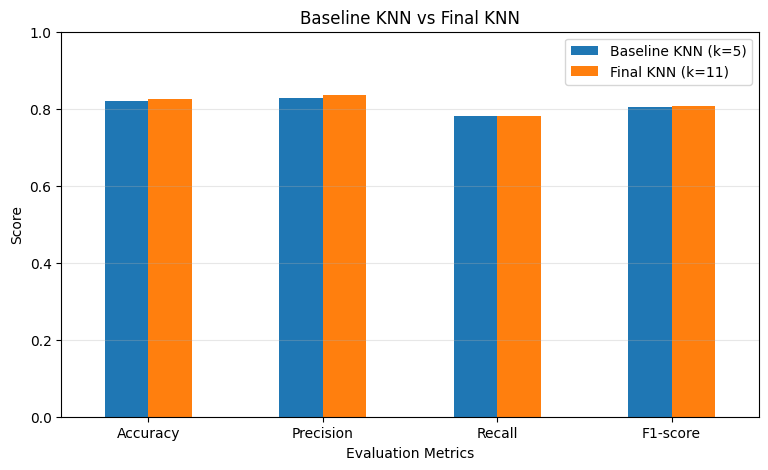

In [73]:
# Visualize Comparison

comparison.plot(
    kind='bar',
    figsize=(9, 5)
)

plt.title('Baseline KNN vs Final KNN')
plt.ylabel('Score')
plt.xlabel('Evaluation Metrics')
plt.xticks(rotation=0)
plt.ylim(0, 1)
plt.legend()
plt.grid(axis='y', alpha=0.3)

plt.show()

Hyper paratmer tuning , Accuracy increased slightly from about 81.7% → 82.4%, meaning the final KNN makes slightly more correct predictions overall.
Precision improved from about 82.0% → 83.6%. This is the clearest improvement. The final model is more reliable when it predicts a customer will subscribe.
Recall decreased slightly from about 78.0% → 77.8%. So k=11 identifies fewer actual subscribers than the baseline.
F1-score improved from about 80.0% → 80.8%, suggesting a slightly better balance between precision and recall.